# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
 # (seleccióna la arquitectura que desees, puedes buscar otras) VGG16, ResNet50, MobileNetV2


## Definiciones de modelos

In [ ]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.

In [3]:
# CNN simple
model_cnn_1 = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])


In [4]:
# CNN más profunda con regularización
model_cnn_2 = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])


In [5]:
# Transfer Learning con VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

base_model.trainable = False

model_vgg = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])


58889256/58889256 [==============================] - 95s 2us/step


## Entrenamiento de modelos.

In [ ]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.

In [6]:
# Cargar CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0


170498071/170498071 [==============================] - 626s 4us/step


In [7]:
# Compilación común
def compile_model(model):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

compile_model(model_cnn_1)
compile_model(model_cnn_2)
compile_model(model_vgg)


In [8]:
# Entrenamiento
history_cnn_1 = model_cnn_1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

history_cnn_2 = model_cnn_2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

history_vgg = model_vgg.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10


625/625 [==============================] - 25s 38ms/step - loss: 1.5268 - accuracy: 0.4514 - val_loss: 1.2811 - val_accuracy: 0.5436
Epoch 2/10
625/625 [==============================] - 26s 42ms/step - loss: 1.1598 - accuracy: 0.5935 - val_loss: 1.0978 - val_accuracy: 0.6171
Epoch 3/10
625/625 [==============================] - 23s 37ms/step - loss: 1.0194 - accuracy: 0.6435 - val_loss: 1.0570 - val_accuracy: 0.6345
Epoch 4/10
625/625 [==============================] - 23s 37ms/step - loss: 0.9264 - accuracy: 0.6785 - val_loss: 0.9985 - val_accuracy: 0.6540
Epoch 5/10
625/625 [==============================] - 24s 39ms/step - loss: 0.8509 - accuracy: 0.7053 - val_loss: 0.9716 - val_accuracy: 0.6668
Epoch 6/10
625/625 [==============================] - 23s 38ms/step - loss: 0.7854 - accuracy: 0.7269 - val_loss: 0.9095 - val_accuracy: 0.6932
Epoch 7/10
625/625 [==============================] - 25s 40ms/step - loss: 0.7182 - accuracy: 0.7521 - val_loss: 0.9137 - val_accurac

## Estadística y gráficos

In [ ]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.

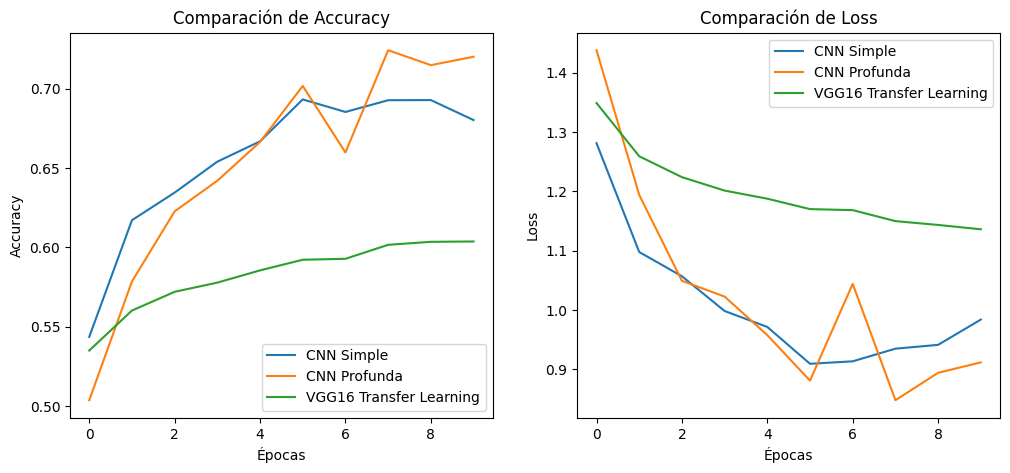

In [9]:
def plot_history(histories, labels):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    for h, l in zip(histories, labels):
        plt.plot(h.history['val_accuracy'], label=l)
    plt.title('Comparación de Accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    for h, l in zip(histories, labels):
        plt.plot(h.history['val_loss'], label=l)
    plt.title('Comparación de Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(
    [history_cnn_1, history_cnn_2, history_vgg],
    ['CNN Simple', 'CNN Profunda', 'VGG16 Transfer Learning']
)


# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

Conclusiones
En esta actividad se compararon tres arquitecturas convolucionales para clasificación de imágenes en CIFAR-10.
La CNN simple mostró un desempeño básico, mientras que la CNN más profunda logró una mejor generalización gracias al uso de más capas y regularización.
El modelo con Transfer Learning (VGG16) obtuvo el mejor desempeño, ya que aprovecha características previamente aprendidas en ImageNet, demostrando la ventaja de reutilizar modelos preentrenados.
Como mejora futura, se podría realizar fine-tuning del modelo VGG16 y aumentar el uso de data augmentation para mejorar la generalización.